# Replicating Machnes paper results

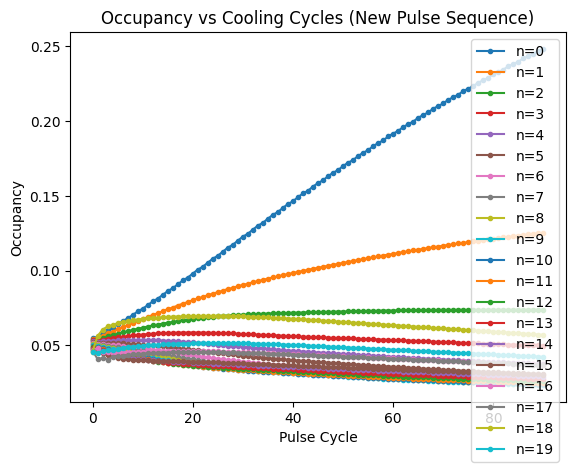

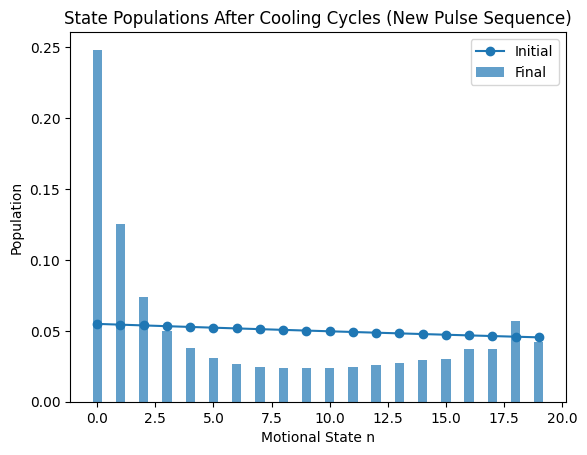

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 1  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
eta = 0.31   # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
Omega = nu
n0 = 1
gamma = 5  # Spin relaxation
kT = 100      # Boltzmann constant times temperature
tau =  2*np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration

# Define operators
N = 20  # Truncation for the Fock space
n_trotter = 10        
Omega_T = 1000  # Boosting Omega to approach Strong Coupling [cite: 10]

dt = 2*np.pi / (5 * eta * Omega_T * np.sqrt(n0))
n_trotter_steps = 180  

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))
X_op = a_full + a_dag_full

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N,1j*eta))

"""Trotter pulse sequence Hamiltonians"""

# 1) X pulse Hamiltonian
H_x = nu * a_dag_full * a_full + 0.5 * Omega_T * (s_plus_full * D_op + s_minus_full * D_op.dag())
L_x = liouvillian(H_x, [])
prop_x = (L_x * dt).expm()

# 3) Y pulse Hamiltonian
H_y = nu * a_dag_full * a_full + 0.5 * Omega_T * (1j * s_plus_full * D_op - 1j * s_minus_full * D_op.dag())
L_y = liouvillian(H_y, [])
prop_y = (L_y * dt).expm()
# Undo Y(π/2)
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * dt).expm()

# Free evolution Hamiltonian
H_free = nu * a_dag_full * a_full
L_free = liouvillian(H_free, [])
prop_free = (L_free * 10*dt).expm()

prop_trotter = prop_y_undo * prop_free * prop_x * prop_y

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# Pumping to ground state propagator
H_diss = nu * a_dag_full * a_full
L_pumping = liouvillian(H_diss, c_ops) 
t_pump = 2.0 / gamma
prop_diss = (L_pumping * t_pump).expm()

# Define pi / 2 Y pulse duration for final step
H_y = nu * a_dag_full * a_full + 0.5 * Omega * (1j * s_plus_full * D_op - 1j * s_minus_full * D_op.dag())
L_y = liouvillian(H_y, [])
prop_y = (L_y * np.pi/2).expm()
# Undo Y(π/2)
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * np.pi/2).expm()

# Free evolution Hamiltonian
H_free = nu * a_dag_full * a_full
L_free = liouvillian(H_free, [])
prop_free = (L_free * dt).expm()

prop_cycle = prop_diss * prop_y_undo * (prop_trotter**n_trotter_steps) * prop_y 

# --- Simulation ---
num_pulses = 90  # Number of cycles
times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = (- nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies_fast = np.zeros((num_pulses + 1, N))
rho_current = operator_to_vector(initial_state)


# Initial occupancy
occupancies_fast[0, :] = initial_state.ptrace(1).diag().real

# Evolve step-by-step under the new pulse sequence
for k in range(1, num_pulses + 1):
    rho_current = prop_cycle * rho_current
    
    # Store data
    rho_mat = vector_to_operator(rho_current)
    occupancies_fast[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies_fast[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies_fast[0, :]
p_motional_final = occupancies_fast[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

Pulse duration tau: 12566.37
Dissipation duration tau_diss: 50.00


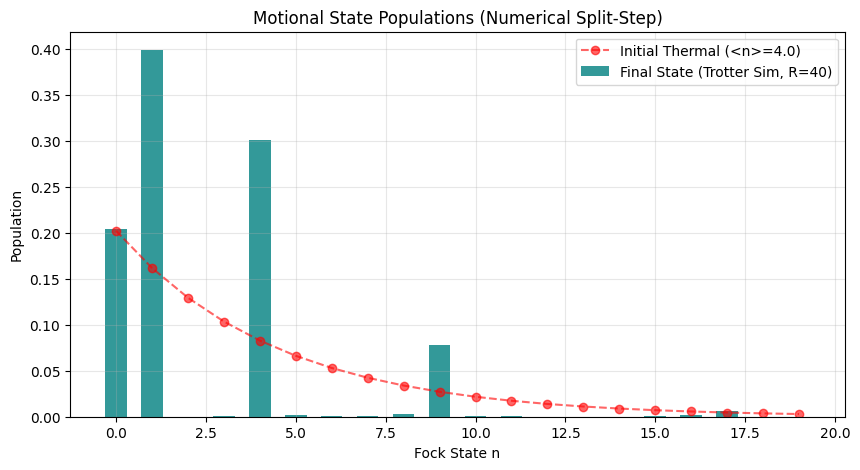

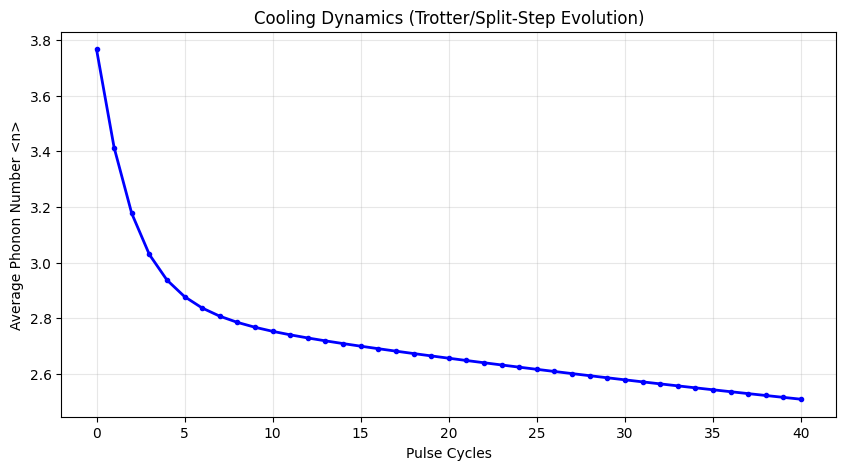

In [7]:

# --- 1. System Parameters (based on Paper Section 7) ---
N = 20              # Truncation for Fock space
eta = 0.05          # Lamb-Dicke parameter
# Section 7.2.3 suggests Omega approx 3 orders magnitude smaller than nu for stability
Omega = 0.01        # Rabi frequency
nu = 1.0            # Trap frequency
Delta = 1.0         # Detuning (Paper sets Delta=nu for RSB resonance [cite: 78])
n0 = 1              # Target trap level
n_thermal = 4.0     # Initial average phonon number
num_cycles = 40     # Number of repetitions (R)

# Pulse duration tau (Eq 2 condition)
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))
# Dissipation duration (needs to be sufficient to relax the spin, usually > 1/Gamma)
Gamma = 0.1         # Decay rate
tau_diss = 5 / Gamma # Time for spontaneous emission to occur

print(f"Pulse duration tau: {tau:.2f}")
print(f"Dissipation duration tau_diss: {tau_diss:.2f}")

# --- 2. Operators ---
a = destroy(N)
a_dag = a.dag()
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()

# Full Hilbert Space
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)

# --- 3. Hamiltonians (Paper Eq. 1) ---
# The paper suggests using the Full Hamiltonian for numerics to capture off-resonant effects [cite: 416]
# H = Delta/2 * sz + nu * a_dag * a + Omega/2 * (s+ * D(i*eta) + s- * D_dag(i*eta))

# Displacement Operator D(i*eta) expansion approx for small eta: 1 + i*eta*(a+a_dag)
# Or use exact displacement:
D_op = tensor(qeye(2), displace(N, 1j * eta))

H_full = (Delta / 2.0) * s_z_full + \
         nu * a_dag_full * a_full + \
         (Omega / 2.0) * (s_plus_full * D_op + s_minus_full * D_op.dag())

# --- 4. Trotter / Split-Step Propagators ---

# Step A: Unitary Evolution (Laser Pulse)
# Evolution under H_full for time tau with NO dissipation
L_unitary = liouvillian(H_full, []) 
prop_unitary = (L_unitary * tau).expm()

# Step B: Dissipative Evolution (Measurement/Reset)
# Evolution with NO Hamiltonian (or just free energy) and Collapse Ops
# Paper Eq (23) includes spontaneous emission.
# Simple model: Decay from |e> to |g>
c_ops = [np.sqrt(Gamma) * s_minus_full]

# We assume H_free during decay (optional, paper splits fully )
# L_diss = liouvillian(0 * H_full, c_ops) # Pure dissipation
# Or including free evolution during decay:
H_free = (Delta / 2.0) * s_z_full + nu * a_dag_full * a_full
L_diss = liouvillian(H_free, c_ops)

prop_dissip = (L_diss * tau_diss).expm()

# Combined "Trotter" Propagator for one cycle
# Order: First Pulse (Unitary), Then Decay (Dissipative)
prop_cycle = prop_dissip * prop_unitary

# --- 5. Simulation Loop ---

# Initial State: |g> and Thermal Motion
rho_mot_thermal = thermal_dm(N, n_thermal)
psi_g = basis(2, 1) # |g> state
rho_init = tensor(psi_g * psi_g.dag(), rho_mot_thermal)

occupancies_initial = rho_mot_thermal.diag()
occupancies_final = np.zeros(N)
avg_energy = []

rho_current = operator_to_vector(rho_init)

# Calculate initial energy
n_start = expect(a_dag_full * a_full, rho_init)
avg_energy.append(n_start)

for k in range(num_cycles):
    # Apply the combined cycle propagator
    rho_current = prop_cycle * rho_current
    
    # Store Energy
    rho_current_dm = vector_to_operator(rho_current)
    n_avg = expect(a_dag_full * a_full, rho_current_dm)
    avg_energy.append(n_avg)

# Final Population
rho_final_mot = rho_current_dm.ptrace(1)
occupancies_final = rho_final_mot.diag().real

# --- 6. Plotting ---

# Plot 1: Populations
plt.figure(figsize=(10, 5))
plt.plot(np.arange(N), occupancies_initial, 'ro--', label=f'Initial Thermal (<n>={n_thermal})', alpha=0.6)
plt.bar(np.arange(N), occupancies_final, width=0.6, label=f'Final State (Trotter Sim, R={num_cycles})', color='teal', alpha=0.8)
plt.xlabel('Fock State n')
plt.ylabel('Population')
plt.title('Motional State Populations (Numerical Split-Step)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Energy Evolution
plt.figure(figsize=(10, 5))
plt.plot(range(num_cycles + 1), avg_energy, 'b.-', linewidth=2)
plt.xlabel('Pulse Cycles')
plt.ylabel('Average Phonon Number <n>')
plt.title('Cooling Dynamics (Trotter/Split-Step Evolution)')
plt.grid(True, alpha=0.3)
plt.show()